In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train_df = pd.read_csv('survey.csv')

In [3]:
train_df


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1254,2015-09-12 11:17:21,26,male,United Kingdom,NaN,No,No,Yes,NaN,26-100,...,Somewhat easy,No,No,Some of them,Some of them,No,No,Don't know,No,NaN
1255,2015-09-26 01:07:35,32,Male,United States,IL,No,Yes,Yes,Often,26-100,...,Somewhat difficult,No,No,Some of them,Yes,No,No,Yes,No,NaN
1256,2015-11-07 12:36:58,34,male,United States,CA,No,Yes,Yes,Sometimes,More than 1000,...,Somewhat difficult,Yes,Yes,No,No,No,No,No,No,NaN
1257,2015-11-30 21:25:06,46,f,United States,NC,No,No,No,NaN,100-500,...,Don't know,Yes,No,No,No,No,No,No,No,NaN


In [4]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Timestamp                  1259 non-null   str  
 1   Age                        1259 non-null   int64
 2   Gender                     1259 non-null   str  
 3   Country                    1259 non-null   str  
 4   state                      744 non-null    str  
 5   self_employed              1241 non-null   str  
 6   family_history             1259 non-null   str  
 7   treatment                  1259 non-null   str  
 8   work_interfere             995 non-null    str  
 9   no_employees               1259 non-null   str  
 10  remote_work                1259 non-null   str  
 11  tech_company               1259 non-null   str  
 12  benefits                   1259 non-null   str  
 13  care_options               1259 non-null   str  
 14  wellness_program           1259 non

In [5]:
train_df.columns[train_df.isnull().any()]

Index(['state', 'self_employed', 'work_interfere', 'comments'], dtype='str')

In [6]:
train_df.isnull().sum()

Timestamp                       0
Age                             0
Gender                          0
Country                         0
state                         515
self_employed                  18
family_history                  0
treatment                       0
work_interfere                264
no_employees                    0
remote_work                     0
tech_company                    0
benefits                        0
care_options                    0
wellness_program                0
seek_help                       0
anonymity                       0
leave                           0
mental_health_consequence       0
phys_health_consequence         0
coworkers                       0
supervisor                      0
mental_health_interview         0
phys_health_interview           0
mental_vs_physical              0
obs_consequence                 0
comments                     1095
dtype: int64

In [7]:
#  Assign default values for each data type

defaultInt = 0
defaultString = 'NaN'
defaultFloat = 0.0

# Create lists by data tpe

intFeatures = ['Age']

stringFeatures = ['Gender', 'Country', 'self_employed', 'family_history', 'treatment', 'work_interfere',
                 'no_employees', 'remote_work', 'tech_company', 'anonymity', 'leave', 'mental_health_consequence',
                 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview',
                 'mental_vs_physical', 'obs_consequence', 'benefits', 'care_options', 'wellness_program',
                 'seek_help']

floatFeatures = []

# Clean the NaN's
for feature in train_df:
    if feature in intFeatures:
        train_df[feature] = train_df[feature].fillna(defaultInt)
    elif feature in stringFeatures:
        train_df[feature] = train_df[feature].fillna(defaultString)
    elif feature in floatFeatures:
        train_df[feature] = train_df[feature].fillna(defaultFloat)
    else:
        print('Error: Feature %s not recognized.' % feature)

train_df.head()

Error: Feature Timestamp not recognized.
Error: Feature state not recognized.
Error: Feature comments not recognized.


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [8]:
#lower case all columm's elements
gender = train_df['Gender'].str.lower()

#Select unique elements
gender = train_df['Gender'].unique()

#Made gender groups
male_str = ["male", "m", "male-ish", "maile", "mal", "male (cis)", "make", "male ", "man","msle", "mail", "malr","cis man", "Cis Male", "cis male"]

trans_str = ["trans-female", "something kinda male?", "queer/she/they", "non-binary","nah", "all", "enby", "fluid", "genderqueer", "androgyne", "agender", "male leaning androgynous", "guy (-ish) ^_^", "trans woman", "neuter", "female (trans)", "queer", "ostensibly male, unsure what that really means"]

female_str = ["cis female", "f", "female", "woman",  "femake", "female ","cis-female/femme", "female (cis)", "femail"]

for (row, col) in train_df.iterrows():

    if str.lower(col.Gender) in male_str:
        train_df.loc[train_df['Gender'] == col.Gender, 'Gender'] = 'male'

    if str.lower(col.Gender) in female_str:
        train_df.loc[train_df['Gender'] == col.Gender, 'Gender'] = 'female'

    if str.lower(col.Gender) in trans_str:
        train_df.loc[train_df['Gender'] == col.Gender, 'Gender'] = 'trans'


stk_list = ['A little about you', 'p']
train_df = train_df[~train_df['Gender'].isin(stk_list)]

print(train_df['Gender'].unique())

<StringArray>
['female', 'male', 'trans']
Length: 3, dtype: str


In [9]:
#complete missing age with mean
train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())

# Fill with media() values < 18 and > 120
s = pd.Series(train_df['Age'])
s[s<18] = train_df['Age'].median()
train_df['Age'] = s
s = pd.Series(train_df['Age'])
s[s>120] = train_df['Age'].median()
train_df['Age'] = s

#Ranges of Age
train_df['age_range'] = pd.cut(train_df['Age'], [0,20,30,65,100], labels=["0-20", "21-30", "31-65", "66-100"], include_lowest=True)
#There are only 0.014% of self employed so let's change NaN to NOT self_employed

#Replace "NaN" string from defaultString
train_df['self_employed'] = train_df['self_employed'].replace([defaultString], 'No')

print(train_df['self_employed'].unique())


<StringArray>
['No', 'Yes']
Length: 2, dtype: str


In [10]:
#There are only 0.20% of self work_interfere so let's change NaN to "Don't know
#Replace "NaN" string from defaultString

train_df['work_interfere'] = train_df['work_interfere'].replace([defaultString], 'Don\'t know' )
print(train_df['work_interfere'].unique())

<StringArray>
['Often', 'Rarely', 'Never', 'Sometimes', 'Don't know']
Length: 5, dtype: str


In [11]:
from sklearn.model_selection import train_test_split # define X and y
feature_cols = ['Age', 'Gender', 'family_history','self_employed', 'benefits', 'care_options', 'anonymity', 'leave', 'work_interfere']
X = train_df[feature_cols]
y = train_df.treatment

# split X and y into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=0)

# Create dictionaries for final graph
# Use: methodDict['Stacking'] = accuracy_score
methodDict = {}
rmseDict = ()

In [12]:
X

,Age,Gender,family_history,self_employed,benefits,care_options,anonymity,leave,work_interfere
0,37,female,No,No,Yes,Not sure,Yes,Somewhat easy,Often
1,44,male,No,No,Don't know,No,Don't know,Don't know,Rarely
2,32,male,No,No,No,No,Don't know,Somewhat difficult,Rarely
3,31,male,Yes,No,No,Yes,No,Somewhat difficult,Often
4,31,male,No,No,Yes,No,Don't know,Don't know,Never
...,...,...,...,...,...,...,...,...,...
1254,26,male,No,No,No,No,Don't know,Somewhat easy,Don't know
1255,32,male,Yes,No,Yes,Yes,Yes,Somewhat difficult,Often
1256,34,male,Yes,No,Yes,Yes,Don't know,Somewhat difficult,Sometimes
1257,46,female,No,No,No,Yes,Don't know,Don't know,Don't know


In [13]:
df = pd.DataFrame(X)

In [14]:
y_train

929      No
901     Yes
579     Yes
367     Yes
615     Yes
       ... 
763     Yes
835     Yes
1218     No
559      No
684      No
Name: treatment, Length: 879, dtype: str

In [15]:
X.head(930)

,Age,Gender,family_history,self_employed,benefits,care_options,anonymity,leave,work_interfere
0,37,female,No,No,Yes,Not sure,Yes,Somewhat easy,Often
1,44,male,No,No,Don't know,No,Don't know,Don't know,Rarely
2,32,male,No,No,No,No,Don't know,Somewhat difficult,Rarely
3,31,male,Yes,No,No,Yes,No,Somewhat difficult,Often
4,31,male,No,No,Yes,No,Don't know,Don't know,Never
...,...,...,...,...,...,...,...,...,...
925,29,male,No,No,Yes,No,Don't know,Don't know,Sometimes
926,43,male,Yes,No,Yes,Not sure,Don't know,Don't know,Sometimes
927,29,male,No,No,Yes,Yes,Don't know,Somewhat easy,Don't know
928,25,male,No,No,Yes,No,Yes,Don't know,Don't know


In [16]:
from sklearn import preprocessing

labelDict = {}
for feature in train_df:
    le = preprocessing.LabelEncoder()
    le.fit(train_df[feature])
    le_name_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    train_df[feature] = le.transform(train_df[feature])
    # Get labels
    labelKey = 'label_' + feature
    labelValue = [*le_name_mapping]
    labelDict[labelKey] =labelValue

for key, value in labelDict.items():
    print(key, value)

#Get rid of 'Country'
#train_df = train_df.drop(['Country'], axis= 1)
train_df.head()

label_Timestamp ['2014-08-27 11:29:31', '2014-08-27 11:29:37', '2014-08-27 11:29:44', '2014-08-27 11:29:46', '2014-08-27 11:30:22', '2014-08-27 11:31:22', '2014-08-27 11:31:50', '2014-08-27 11:32:05', '2014-08-27 11:32:39', '2014-08-27 11:32:43', '2014-08-27 11:32:44', '2014-08-27 11:32:49', '2014-08-27 11:33:23', '2014-08-27 11:33:26', '2014-08-27 11:33:57', '2014-08-27 11:34:00', '2014-08-27 11:34:20', '2014-08-27 11:34:37', '2014-08-27 11:34:53', '2014-08-27 11:35:08', '2014-08-27 11:35:12', '2014-08-27 11:35:24', '2014-08-27 11:35:48', '2014-08-27 11:36:24', '2014-08-27 11:36:48', '2014-08-27 11:37:08', '2014-08-27 11:37:23', '2014-08-27 11:37:59', '2014-08-27 11:38:12', '2014-08-27 11:38:18', '2014-08-27 11:38:55', '2014-08-27 11:39:03', '2014-08-27 11:39:31', '2014-08-27 11:39:36', '2014-08-27 11:40:51', '2014-08-27 11:41:17', '2014-08-27 11:41:37', '2014-08-27 11:41:50', '2014-08-27 11:42:08', '2014-08-27 11:42:15', '2014-08-27 11:42:25', '2014-08-27 11:42:31', '2014-08-27 11:43

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments,age_range
0,0,19,0,44,10,0,0,1,2,4,...,1,1,1,2,1,0,2,0,158,2
1,1,26,1,44,11,0,0,0,3,5,...,0,1,0,0,1,1,0,0,158,2
2,2,14,1,6,45,0,0,0,3,4,...,1,1,2,2,2,2,1,0,158,2
3,3,13,1,43,45,0,1,1,2,2,...,2,2,1,0,0,0,1,1,158,2
4,4,13,1,44,37,0,0,0,1,1,...,1,1,1,2,2,2,0,0,158,2


In [17]:
total = train_df.isnull().sum().sort_values(ascending=False)
percent = (train_df.isnull().sum()/train_df.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data.head(20)
print(missing_data)

                           Total  Percent
Timestamp                      0      0.0
Age                            0      0.0
comments                       0      0.0
obs_consequence                0      0.0
mental_vs_physical             0      0.0
phys_health_interview          0      0.0
mental_health_interview        0      0.0
supervisor                     0      0.0
coworkers                      0      0.0
phys_health_consequence        0      0.0
mental_health_consequence      0      0.0
leave                          0      0.0
anonymity                      0      0.0
seek_help                      0      0.0
wellness_program               0      0.0
care_options                   0      0.0
benefits                       0      0.0
tech_company                   0      0.0
remote_work                    0      0.0
no_employees                   0      0.0
work_interfere                 0      0.0
treatment                      0      0.0
family_history                 0  

Text(0.5, 0, 'Age')

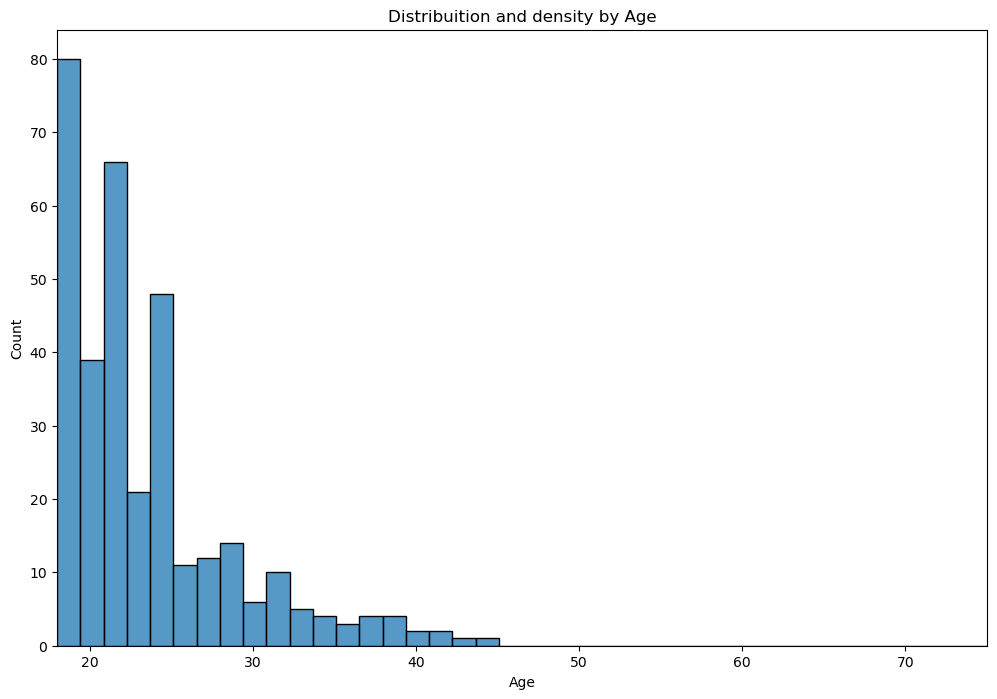

In [18]:
plt.figure(figsize=(12,8))
sns.histplot(train_df["Age"], binrange=(18, 75))
plt.xlim(18, 75)
plt.title("Distribuition and density by Age")
plt.xlabel("Age")

Text(0.5, 1.02, 'Age Distribution by Treatment Status')

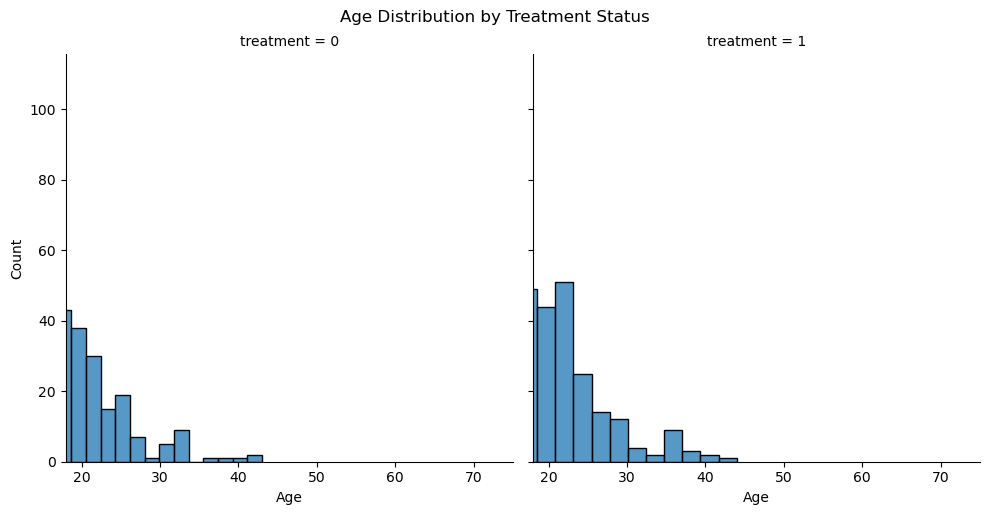

In [19]:
g = sns.FacetGrid(train_df, col='treatment', height=5)
g = g.map(sns.histplot, "Age")
g.set(xlim=(18, 75))
g.fig.suptitle('Age Distribution by Treatment Status', y=1.02)

In [20]:
train_df

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments,age_range
0,0,19,0,44,10,0,0,1,2,4,...,1,1,1,2,1,0,2,0,158,2
1,1,26,1,44,11,0,0,0,3,5,...,0,1,0,0,1,1,0,0,158,2
2,2,14,1,6,45,0,0,0,3,4,...,1,1,2,2,2,2,1,0,158,2
3,3,13,1,43,45,0,1,1,2,2,...,2,2,1,0,0,0,1,1,158,2
4,4,13,1,44,37,0,0,0,1,1,...,1,1,1,2,2,2,0,0,158,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1254,1239,8,1,43,45,0,0,1,0,2,...,1,1,1,1,1,1,0,0,158,1
1255,1240,14,1,44,10,0,1,1,2,2,...,1,1,1,2,1,1,2,0,158,2
1256,1241,16,1,44,2,0,1,1,4,5,...,2,2,0,0,1,1,1,0,158,2
1257,1242,28,0,44,22,0,0,0,0,1,...,2,1,0,0,1,1,1,0,158,2


In [21]:
train_df['self_employed'].unique()

array([0, 1])

In [22]:
train_df['no_employees'].unique()

array([4, 5, 2, 1, 0, 3])

In [23]:
train_df['work_interfere'].unique()

array([2, 3, 1, 4, 0])

In [24]:
from sklearn.model_selection import train_test_split # define X and y
feature_cols = ['Age', 'Gender', 'family_history','self_employed', 'benefits', 'care_options', 'anonymity', 'leave', 'work_interfere']
X = train_df[feature_cols]
y = train_df.treatment

# split X and y into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=0)

# Create dictionaries for final graph
# Use: methodDict['Stacking'] = accuracy_score
methodDict = {}
rmseDict = ()

In [25]:
y_train

929     0
901     1
579     1
367     1
615     1
       ..
763     1
835     1
1218    0
559     0
684     0
Name: treatment, Length: 879, dtype: int64

In [26]:
X_train

,Age,Gender,family_history,self_employed,benefits,care_options,anonymity,leave,work_interfere
929,13,1,1,0,0,0,0,4,1
901,25,1,1,0,1,0,0,3,3
579,16,1,1,0,2,0,0,0,4
367,18,1,1,0,1,2,2,4,2
615,12,1,0,1,1,1,0,1,2
...,...,...,...,...,...,...,...,...,...
763,20,1,1,0,1,0,1,3,4
835,26,1,1,0,0,0,0,1,4
1218,10,1,0,0,1,1,0,2,0
559,6,1,0,0,0,1,0,0,0


**RANDOM FOREST ALGORITHM**

In [27]:
from sklearn.metrics import accuracy_score

from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(max_depth = None, min_samples_leaf=8, min_samples_split=2, n_estimators = 20, random_state = 1)
forest.fit(X_train, y_train)

y_pred_class = forest.predict(X_test)

print("Training Accuracy: ",forest.score(X_train,y_train))
print("Test Accuracy: ",accuracy_score(y_test,y_pred_class,normalize=True))

Training Accuracy:  0.8555176336746303
Test Accuracy:  0.8121693121693122


**SVM algorithm**

In [28]:
#Import svm model
from sklearn import svm

#Create a svm Classifier
clf = svm.SVC(kernel='linear') # Linear Kernel

#Train the model using the training sets
clf.fit(X_train, y_train)

#Predict the response for test dataset
y_pred = clf.predict(X_test)

In [29]:
#Import scikit-learn metrics module for accuracy calculation
from sklearn import metrics

# Model Accuracy: how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.7751322751322751


In [30]:
# Model Precision: what percentage of positive tuples are labeled as such?
print("Precision:",metrics.precision_score(y_test, y_pred))

# Model Recall: what percentage of positive tuples are labelled as such?
print("Recall:",metrics.recall_score(y_test, y_pred))

Precision: 0.7318181818181818
Recall: 0.8609625668449198


**DECISION TREE**

In [31]:
from sklearn.tree import DecisionTreeClassifier
# Create Decision Tree classifer object
clf = DecisionTreeClassifier()

# Train Decision Tree Classifer
clf = clf.fit(X_train,y_train)

#Predict the response for test dataset
y_pred = clf.predict(X_test)


In [32]:
# Model Accuracy, how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.753968253968254


In [33]:
# Create Decision Tree classifer object
clf = DecisionTreeClassifier(criterion="entropy", max_depth=3)

# Train Decision Tree Classifer
clf = clf.fit(X_train,y_train)

#Predict the response for test dataset
y_pred = clf.predict(X_test)

# Model Accuracy, how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.8068783068783069


**KNN**

In [34]:
#Import knearest neighbors Classifier model
from sklearn.neighbors import KNeighborsClassifier

#Create KNN Classifier
knn = KNeighborsClassifier(n_neighbors=5)

#Train the model using the training sets
knn.fit(X_train, y_train)

#Predict the response for test dataset
y_pred = knn.predict(X_test)


In [35]:
#Import scikit-learn metrics module for accuracy calculation
from sklearn import metrics
# Model Accuracy, how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.7486772486772487


In [36]:
#Import knearest neighbors Classifier model
from sklearn.neighbors import KNeighborsClassifier

#Create KNN Classifier
knn = KNeighborsClassifier(n_neighbors=7)

#Train the model using the training sets
knn.fit(X_train, y_train)

#Predict the response for test dataset
y_pred = knn.predict(X_test)

In [37]:
#Import scikit-learn metrics module for accuracy calculation
from sklearn import metrics
# Model Accuracy, how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.7566137566137566
